In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
creditDF= pd.read_csv("creditcard_2023.csv")


In [3]:
creditDF.shape


(568630, 31)

In [4]:
creditDF.info()
creditDF.isnull().sum()
creditDF

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,568625,-0.833437,0.061886,-0.899794,0.904227,-1.002401,0.481454,-0.370393,0.189694,-0.938153,...,0.167503,0.419731,1.288249,-0.900861,0.560661,-0.006018,3.308968,0.081564,4394.16,1
568626,568626,-0.670459,-0.202896,-0.068129,-0.267328,-0.133660,0.237148,-0.016935,-0.147733,0.483894,...,0.031874,0.388161,-0.154257,-0.846452,-0.153443,1.961398,-1.528642,1.704306,4653.40,1
568627,568627,-0.311997,-0.004095,0.137526,-0.035893,-0.042291,0.121098,-0.070958,-0.019997,-0.122048,...,0.140788,0.536523,-0.211100,-0.448909,0.540073,-0.755836,-0.487540,-0.268741,23572.85,1
568628,568628,0.636871,-0.516970,-0.300889,-0.144480,0.131042,-0.294148,0.580568,-0.207723,0.893527,...,-0.060381,-0.195609,-0.175488,-0.554643,-0.099669,-1.434931,-0.159269,-0.076251,10160.83,1


# EDA - exploratory data analysis

Text(0.5, 1.0, 'How balanced data is !')

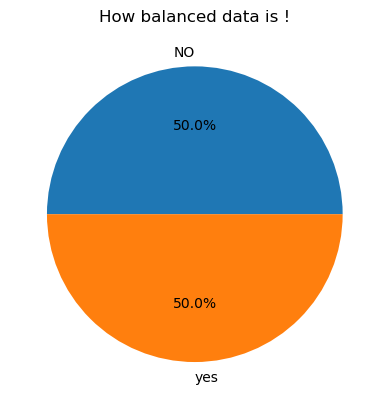

In [5]:
# how balanced the data is !
class_count= creditDF["Class"].value_counts()

plt.pie(class_count, labels = ["NO","yes"],autopct= "%1.1f%%")
plt.title("How balanced data is !")

In [6]:
creditDF.columns


Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

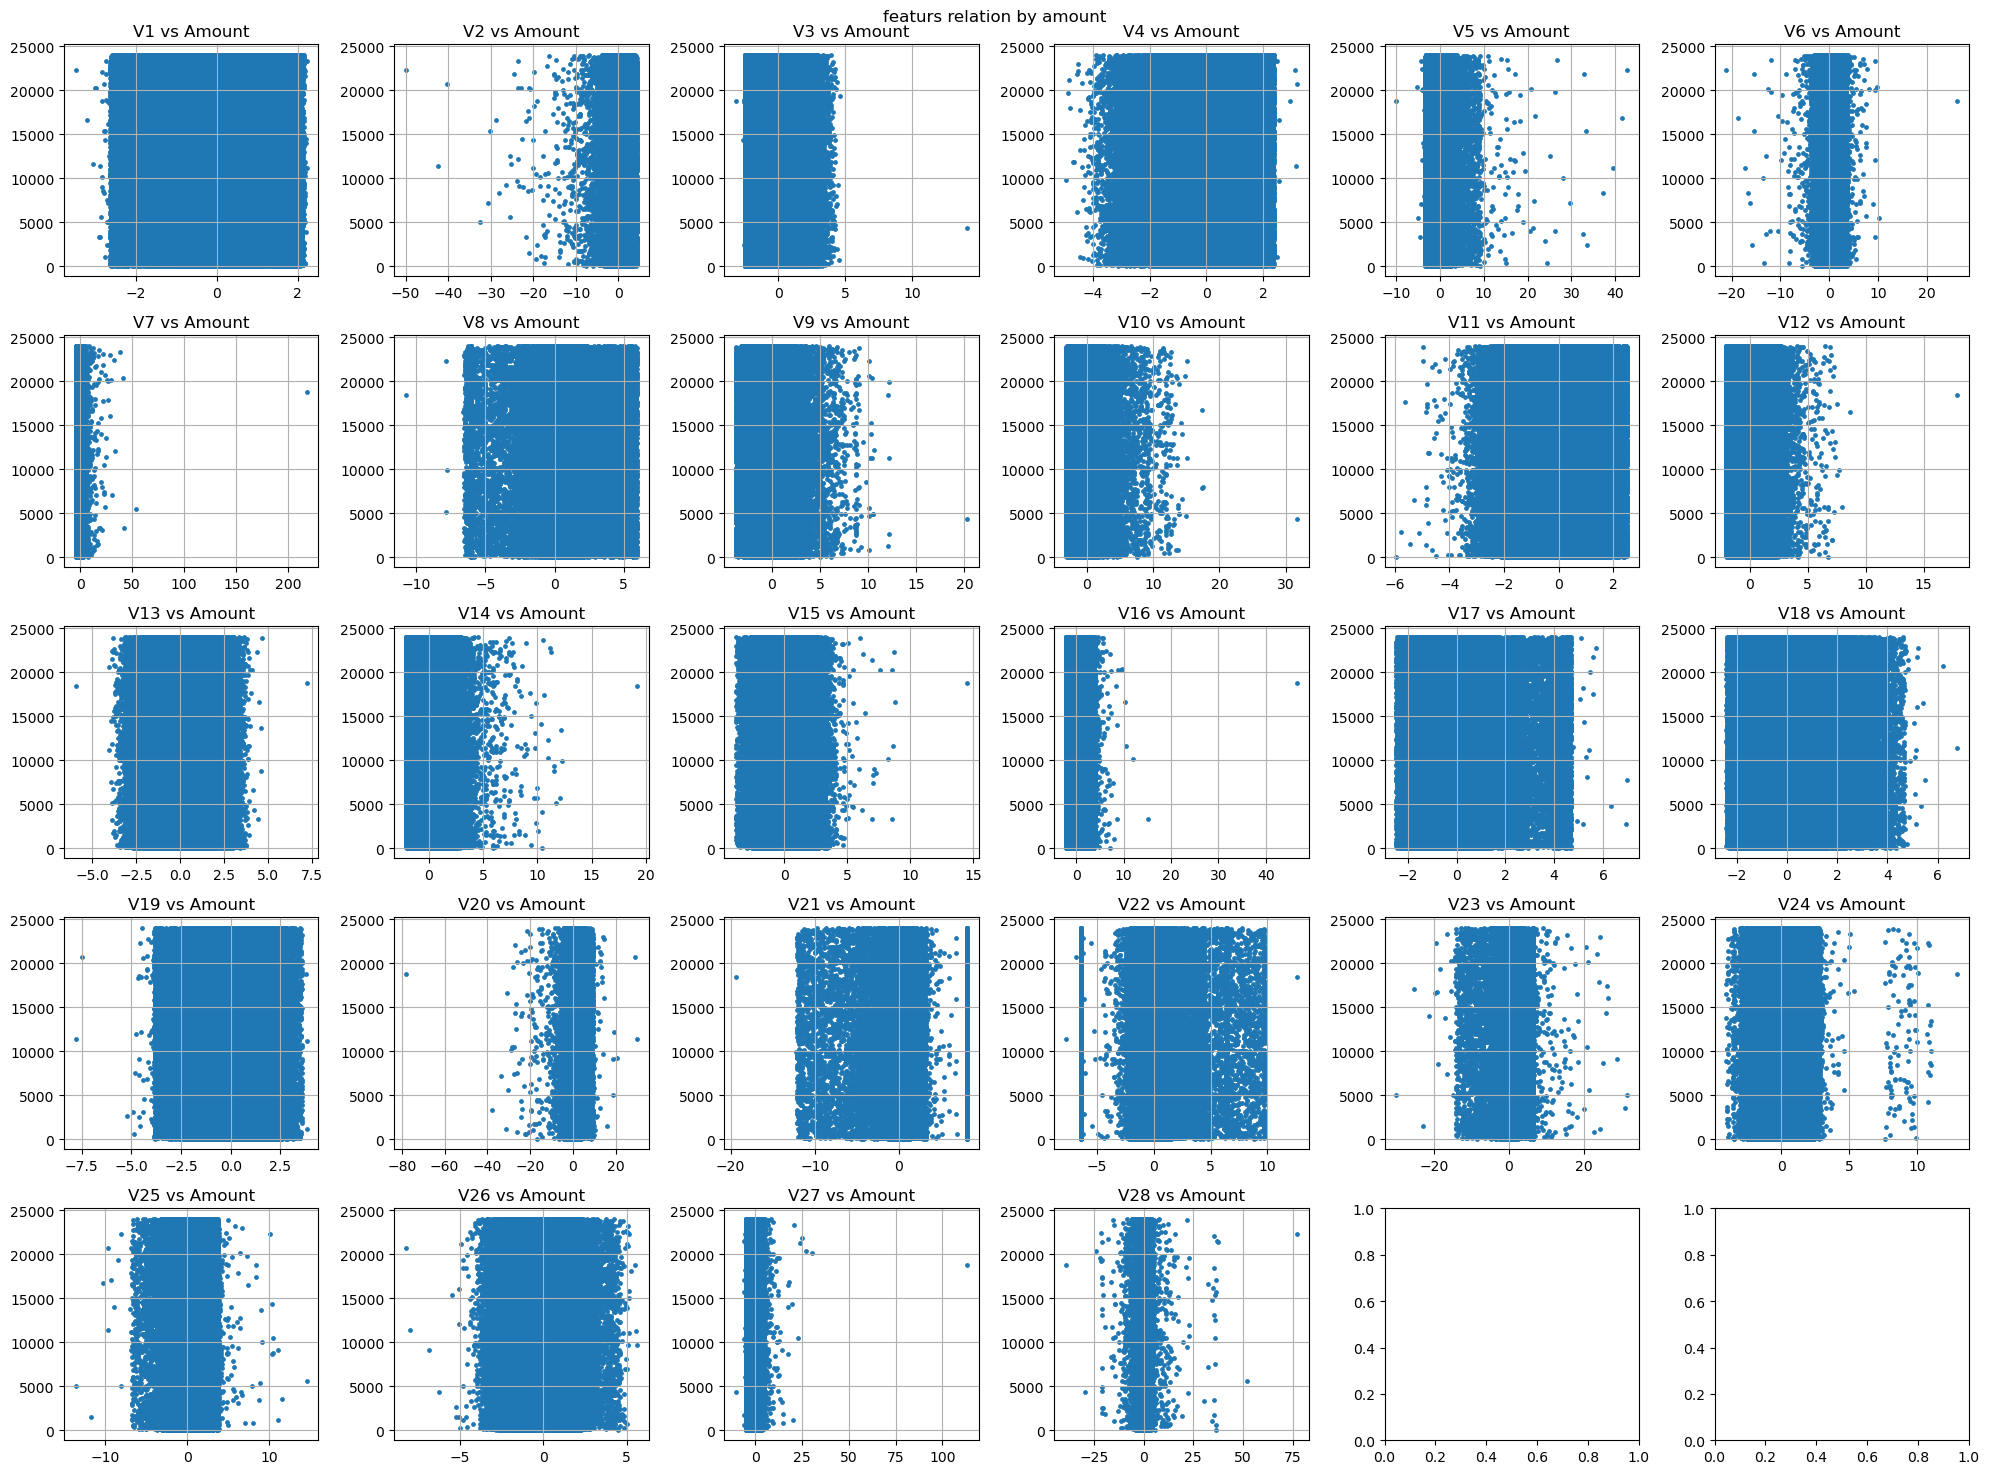

In [7]:
x = creditDF[["V1", "V2", "V3", "V4", "V5", "V6",
              "V7", "V8", "V9", "V10", "V11", "V12",
              "V13", "V14", "V15", "V16", "V17", "V18",
              "V19", "V20", "V21", "V22", "V23", "V24",
              "V25", "V26", "V27", "V28"]]

y = creditDF["Amount"]

fig, ax = plt.subplots(5, 6, figsize=(20,15))

ax = ax.flatten()

for i, col in enumerate(x.columns):

    ax[i].scatter(creditDF[col],
                  creditDF["Amount"],
                  s=6)

    ax[i].set_title(f"{col} vs Amount")

    ax[i].grid(True)

fig.suptitle("featurs relation by amount")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'analyze amount')

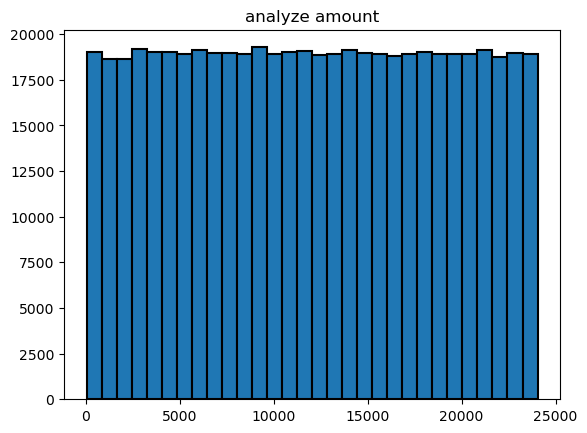

In [8]:
# amount related to classes

plt.hist(data=creditDF,x="Amount",bins=30,linewidth=1.5,edgecolor="black")
plt.title("analyze amount")

<Axes: xlabel='Class', ylabel='Amount'>

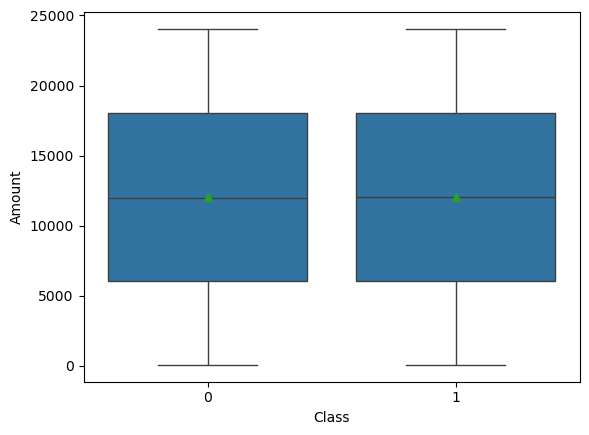

In [9]:
sns.boxplot(data=creditDF, x="Class",y="Amount",showmeans= True)      

In [10]:
creditDF=creditDF.drop("id", axis=1)

In [11]:
creditDF.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


## correlation HeatMap

<Axes: >

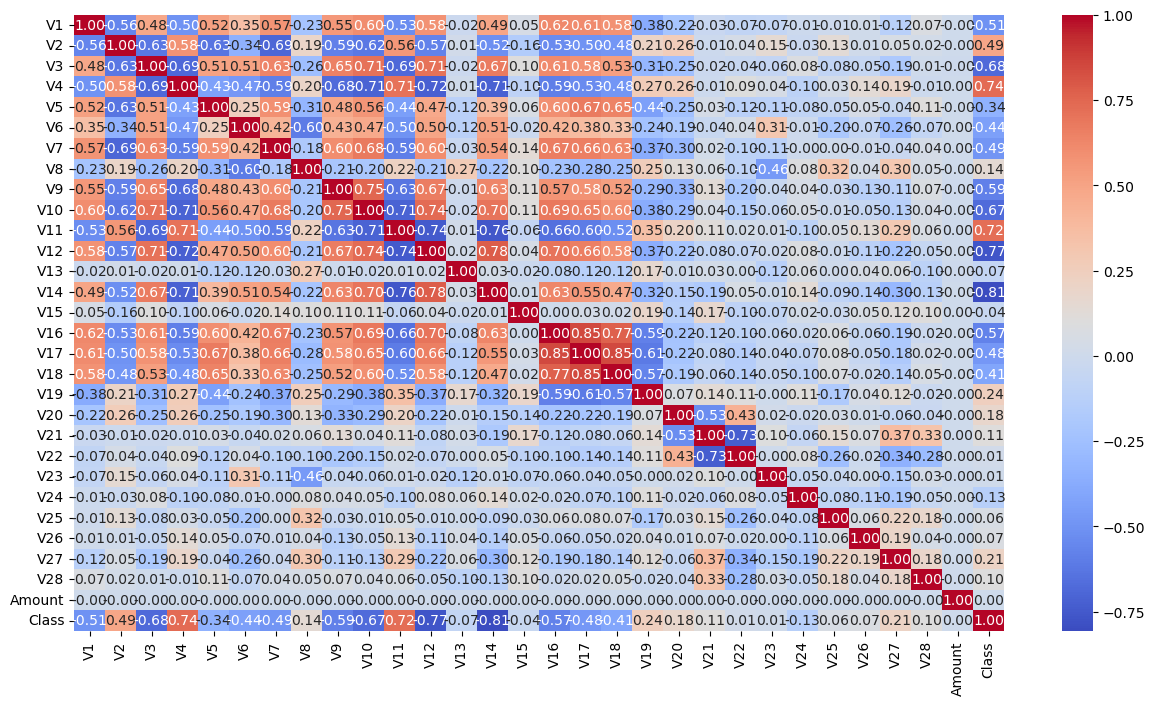

In [12]:
num_cols= creditDF.select_dtypes(include="number")

corr_matrix= num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    fmt=".2f",
    annot=True,
    cmap="coolwarm"
)

In [13]:
num_cols.corr()["Class"].sort_values(ascending=False)
## V4,V11 ,V2 hvae high correlation and V3, V12 ,V14 have losest correlation 
# even Amount have less correlation with class 

Class     1.000000
V4        0.735981
V11       0.724278
V2        0.491878
V19       0.244081
V27       0.214002
V20       0.179851
V8        0.144294
V21       0.109640
V28       0.102024
V26       0.071052
V25       0.061847
V22       0.014098
V23       0.010255
Amount    0.002261
V15      -0.037948
V13      -0.071105
V24      -0.130107
V5       -0.338639
V18      -0.410091
V6       -0.435088
V17      -0.476377
V7       -0.491234
V1       -0.505761
V16      -0.573511
V9       -0.585522
V10      -0.673665
V3       -0.682095
V12      -0.768579
V14      -0.805669
Name: Class, dtype: float64

## Train- Test - Slipt & Feature Scaling

In [14]:
X= creditDF.drop("Class", axis=1)
Y= creditDF["Class"]

In [15]:
from sklearn.model_selection import train_test_split
#from  sklearn.model_selection import train_test_slipt

In [16]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y ,test_size=0.3,random_state=42)

In [17]:
X_test.shape
X_train.shape

(398041, 29)

In [18]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
400282,-0.363223,0.663551,-0.744452,1.254839,-0.040747,-0.511713,-0.556703,0.079769,-0.870520,-0.992748,...,0.639771,0.309951,0.439658,-0.397237,-0.795695,-0.052595,0.313695,0.659813,0.029500,14545.27
439696,0.365635,-0.005367,-0.096653,0.353750,-0.186671,-0.258307,-0.170350,-0.028947,-0.176576,-0.361248,...,0.164321,0.063773,-0.014859,-0.115594,0.917145,0.945081,0.761912,0.483889,0.634776,4385.61
175832,-0.211985,-0.811944,0.485130,0.434157,1.803325,-0.066885,0.406729,-0.114204,0.031242,1.027604,...,0.070429,0.091557,0.797416,0.728314,1.337360,-2.450779,-0.923252,0.051270,0.873582,7384.92
251646,0.025550,-0.288214,1.597869,-0.420011,0.221625,0.842837,0.568994,-0.096953,0.624953,0.366601,...,-0.042604,-0.039059,0.316322,0.069351,0.892595,-0.760222,-1.884455,0.004224,0.382780,13521.92
112160,-0.160379,-0.597804,2.953146,0.084842,-0.009268,1.125643,0.297598,-0.028493,1.072541,0.316919,...,0.272598,-0.056601,0.464498,0.066064,0.290821,0.639777,-0.023464,-0.159843,-0.044691,10735.48


In [19]:
from sklearn.preprocessing import StandardScaler


In [20]:
scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
X_train_scaled

array([[-0.36428215,  0.66556759, -0.74619088, ...,  0.65707104,
         0.02920348,  0.36114487],
       [ 0.36515982, -0.00394602, -0.09775464, ...,  0.48170551,
         0.63433099, -1.10653897],
       [-0.21292365, -0.81123996,  0.4845999 , ...,  0.05046185,
         0.87307738, -0.67325293],
       ...,
       [-0.98759012, -0.24011673, -0.80725275, ...,  2.00391505,
         0.81373875,  0.99659235],
       [ 0.13585547, -0.1295624 ,  1.50655683, ..., -0.37214837,
        -0.57570176, -0.75246573],
       [ 1.01946899, -0.72948896,  0.67829014, ..., -0.23632726,
        -0.00711663, -1.45546648]], shape=(398041, 29))

# Train & Evaluate Model

In [22]:
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
#from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [23]:
log_model=LogisticRegression()

log_model.fit(X_train_scaled, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
LOG_y_pred= log_model.predict(X_test_scaled)

In [25]:
# Evaluation
from sklearn.metrics import classification_report

print("Logistic Regression Model")
print("Precision: ", precision_score(Y_test, LOG_y_pred))
print("Recall: ", recall_score(Y_test, LOG_y_pred))
print("F1 score: ", f1_score(Y_test, LOG_y_pred))
print("Accuracy: ", accuracy_score(Y_test, LOG_y_pred))
print("CM: ", confusion_matrix(Y_test, LOG_y_pred))

Logistic Regression Model
Precision:  0.9774816948745649
Recall:  0.9531132958801498
F1 score:  0.9651437037037037
Accuracy:  0.9655194649127435
CM:  [[83273  1876]
 [ 4006 81434]]


In [26]:
## SVM
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [28]:
pipeline= Pipeline([('scaler',StandardScaler()),('svc',SVC(C=1.0,kernel='rbf'))])

In [ ]:
pipeline.fit(X_train,Y_train)

In [ ]:
y_pred=pipeline.predict(X_test)
#x_pred=pipeline.predict(X_train)

In [ ]:
print("SVC Model")
print("classication report : ", classification_report(Y_test, y_pred))
print("Precision: ", precision_score(Y_test, y_pred))
print("Recall: ", recall_score(Y_test, y_pred))
print("F1 score: ", f1_score(Y_test, y_pred))
#print("Accuracy on training data: ", accuracy_score(Y_train, y_pred))
print("Accuracy: ", accuracy_score(Y_test, y_pred))
print("CM: ", confusion_matrix(Y_test, y_pred))

In [29]:
import xgboost as xgb

In [30]:
model_xgb=xgb.XGBClassifier(
    n_estimators =100,
    max_depth =6,
    learning_rate =0.1,
    eval_metric ="logloss",
    random_state=42
)

In [31]:
model_xgb.fit(X_train_scaled,Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [32]:
xgb_y_pred=model_xgb.predict(X_test_scaled)
xgb_X_pred=model_xgb.predict(X_train_scaled)

In [33]:
print("classication report : ", classification_report(Y_test, xgb_y_pred))
print("Precision: ", precision_score(Y_test, xgb_y_pred))
print("Recall: ", recall_score(Y_test, xgb_y_pred))
print("F1 score: ", f1_score(Y_test, xgb_y_pred))

print("Accuracy on train data: ", accuracy_score(Y_train, xgb_X_pred))
print("Accuracy: ", accuracy_score(Y_test, xgb_y_pred))

print("CM: ", confusion_matrix(Y_test, xgb_y_pred))

classication report :                precision    recall  f1-score   support

           0       1.00      1.00      1.00     85149
           1       1.00      1.00      1.00     85440

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589

Precision:  0.9971944918523368
Recall:  0.9984316479400749
F1 score:  0.9978126864187711
Accuracy on train data:  0.9981182842973463
Accuracy:  0.9978075960349143
CM:  [[84909   240]
 [  134 85306]]


## Comparion of models

In [34]:
print("XGBOOST model")
print("Recall: ", recall_score(Y_test, xgb_y_pred))
print("Accuracy: ", accuracy_score(Y_test, xgb_y_pred))

print("SVC model")
print("Recall: ", recall_score(Y_test, y_pred))
print("Accuracy: ", accuracy_score(Y_test, y_pred))


print("Logistic Regression Model")
print("Recall: ", recall_score(Y_test, LOG_y_pred))
print("Accuracy: ", accuracy_score(Y_test, LOG_y_pred))

XGBOOST model
Recall:  0.9984316479400749
Accuracy:  0.9978075960349143
SVC model


NameError: name 'y_pred' is not defined

### Save & Load model by joblib

In [35]:
import joblib


In [36]:
joblib.dump(model_xgb,"C:/Users/vadlu/AIML/projects/FraudShield/models/fraud_model.pkl")
joblib.dump(scaler,"C:/Users/vadlu/AIML/projects/FraudShield/models/scaler.pkl")

['C:/Users/vadlu/AIML/projects/FraudShield/models/scaler.pkl']

In [37]:
# propbabaliti analyze of transaction 
transaction= X_test.iloc[[0]]


prediction= model_xgb.predict(transaction)
probability= model_xgb.predict_proba(transaction)


# prediction and probability
print(prediction)
print(probability)

[1]
[[4.0608644e-04 9.9959391e-01]]


### risk score analyze

In [38]:
risk_score = probability[0][1]*100


In [39]:
print(f"{risk_score:.0f}%")

100%


### risk level

In [40]:
if risk_score>=80:
    risk="HIGH RISK"
elif risk_score>=50:
    risk="MEDIUM RISK"
else:
    risk="LOW RISK"

print(risk)

HIGH RISK
